In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("fod_incidents_200k_10cols.csv")

In [4]:
data.head()

,Incident_ID,Date,Location,Department,Object_Type,Severity,Incident_Count,Shift,Inspection_Type,Weather_Condition
0,1,2024-05-17,Tool Room,Maintenance,Plastic,Low,3.0,Night,Random Inspection,Clear
1,2,2024-03-07,Maintenance Bay,Logistics,Tool,Medium,2.0,Evening,Random Inspection,Dusty
2,3,2024-10-16,Assembly Line,Maintenance,Plastic,Medium,2.0,Morning,Routine Check,Rainy
3,4,2024-03-30,Maintenance Bay,Logistics,Bolt/Nut,Low,1.0,Night,Routine Check,Humid
4,5,2024-07-23,Runway,Quality,Plastic,High,3.0,Morning,Random Inspection,Humid


In [5]:
data.tail()

,Incident_ID,Date,Location,Department,Object_Type,Severity,Incident_Count,Shift,Inspection_Type,Weather_Condition
50435,50436,2024-05-29,Runway,Logistics,Bolt/Nut,Low,2.0,Evening,Routine Check,Clear
50436,50437,2024-03-14,Runway,Maintenance,Wire,Low,2.0,Evening,Random Inspection,Rainy
50437,50438,2024-06-29,Maintenance Bay,Maintenance,Wire,Low,3.0,Evening,Random Inspection,Rainy
50438,50439,2024-12-08,Maintenance Bay,Logistics,Wire,Low,3.0,Evening,Random Inspection,Dusty
50439,50440,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data.shape

(50440, 10)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50440 entries, 0 to 50439
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Incident_ID        50440 non-null  int64  
 1   Date               50440 non-null  object 
 2   Location           50439 non-null  object 
 3   Department         50439 non-null  object 
 4   Object_Type        50439 non-null  object 
 5   Severity           50439 non-null  object 
 6   Incident_Count     50439 non-null  float64
 7   Shift              50439 non-null  object 
 8   Inspection_Type    50439 non-null  object 
 9   Weather_Condition  50439 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.8+ MB


In [14]:
data['Incident_Count']=data['Incident_Count'].fillna(0).astype(int)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50440 entries, 0 to 50439
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Incident_ID        50440 non-null  int64 
 1   Date               50440 non-null  object
 2   Location           50439 non-null  object
 3   Department         50439 non-null  object
 4   Object_Type        50439 non-null  object
 5   Severity           50439 non-null  object
 6   Incident_Count     50440 non-null  int64 
 7   Shift              50439 non-null  object
 8   Inspection_Type    50439 non-null  object
 9   Weather_Condition  50439 non-null  object
dtypes: int64(2), object(8)
memory usage: 3.8+ MB


In [17]:
data.describe()

,Incident_ID,Incident_Count
count,50440.000000,50440.000000
mean,25220.500000,2.005492
std,14560.918126,0.816247
min,1.000000,0.000000
25%,12610.750000,1.000000
50%,25220.500000,2.000000
75%,37830.250000,3.000000
max,50440.000000,3.000000


In [19]:
data.describe(include='all')

,Incident_ID,Date,Location,Department,Object_Type,Severity,Incident_Count,Shift,Inspection_Type,Weather_Condition
count,50440.000000,50440,50439,50439,50439,50439,50440.000000,50439,50439,50439
unique,NaN,366,6,4,6,3,NaN,3,3,4
top,NaN,2024-04-15,Runway,Quality,Wire,Low,NaN,Morning,Routine Check,Rainy
freq,NaN,175,8490,12702,8588,30475,NaN,16877,16940,12845
mean,25220.500000,NaN,NaN,NaN,NaN,NaN,2.005492,NaN,NaN,NaN
std,14560.918126,NaN,NaN,NaN,NaN,NaN,0.816247,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,12610.750000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
50%,25220.500000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
75%,37830.250000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN


In [20]:
data.isna().sum()

,0
Incident_ID,0
Date,0
Location,1
Department,1
Object_Type,1
Severity,1
Incident_Count,0
Shift,1
Inspection_Type,1
Weather_Condition,1


In [21]:
data.duplicated().sum()

np.int64(0)

In [23]:
data.drop_duplicates(inplace=True)

In [26]:
data.nunique()


,0
Incident_ID,50440
Date,366
Location,6
Department,4
Object_Type,6
Severity,3
Incident_Count,4
Shift,3
Inspection_Type,3
Weather_Condition,4


In [27]:
data['Date']=pd.to_datetime(data['Date'])

ValueError: time data "20" doesn't match format "%Y-%m-%d", at position 365. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [30]:
data.tail(1)

,Incident_ID,Date,Location,Department,Object_Type,Severity,Incident_Count,Shift,Inspection_Type,Weather_Condition
50439,50440,20,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN


In [31]:
data.drop(50439,inplace=True)

In [32]:
data['Date']=pd.to_datetime(data['Date'])

In [33]:
data['month']=data['Date'].dt.month

In [34]:
data.head()

,Incident_ID,Date,Location,Department,Object_Type,Severity,Incident_Count,Shift,Inspection_Type,Weather_Condition,month
0,1,2024-05-17,Tool Room,Maintenance,Plastic,Low,3,Night,Random Inspection,Clear,5
1,2,2024-03-07,Maintenance Bay,Logistics,Tool,Medium,2,Evening,Random Inspection,Dusty,3
2,3,2024-10-16,Assembly Line,Maintenance,Plastic,Medium,2,Morning,Routine Check,Rainy,10
3,4,2024-03-30,Maintenance Bay,Logistics,Bolt/Nut,Low,1,Night,Routine Check,Humid,3
4,5,2024-07-23,Runway,Quality,Plastic,High,3,Morning,Random Inspection,Humid,7


UNIVARIATE ANALYSIS


In [35]:
data['Location'].value_counts()

,count
Location,
Runway,8490
Maintenance Bay,8426
Assembly Line,8403
Storage Area,8391
Tool Room,8373
Hangar,8356


<Axes: xlabel='Location'>

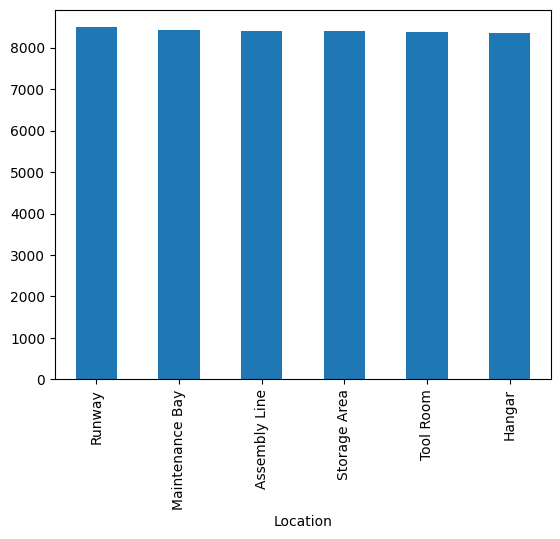

In [36]:
data['Location'].value_counts().plot(kind='bar')

In [37]:
data["Object_Type"].value_counts()

,count
Object_Type,
Wire,8588
Bolt/Nut,8448
Plastic,8434
Metal Scrap,8414
Packaging Material,8345
Tool,8210


In [38]:
data["Object_Type"].value_counts()

,count
Object_Type,
Wire,8588
Bolt/Nut,8448
Plastic,8434
Metal Scrap,8414
Packaging Material,8345
Tool,8210


In [39]:
data["Shift"].value_counts()

,count
Shift,
Morning,16877
Evening,16856
Night,16706


In [40]:
data["Weather_Condition"].value_counts()

,count
Weather_Condition,
Rainy,12845
Humid,12632
Dusty,12618
Clear,12344


Bivariate Analysis

In [44]:
data.groupby(['Location'])[['Incident_Count']].sum()

,Incident_Count
Location,
Assembly Line,16841
Hangar,16726
Maintenance Bay,16874
Runway,17137
Storage Area,16878
Tool Room,16701


In [45]:
data.groupby("Department")["Incident_Count"].sum()

,Incident_Count
Department,
Logistics,25045
Maintenance,25388
Production,25291
Quality,25433


In [46]:
data.groupby("Department")["Incident_Count"].sum()

,Incident_Count
Department,
Logistics,25045
Maintenance,25388
Production,25291
Quality,25433


Time Based Analysis

In [47]:
data['Date']

,Date
0,2024-05-17
1,2024-03-07
2,2024-10-16
3,2024-03-30
4,2024-07-23
...,...
50434,2024-11-25
50435,2024-05-29
50436,2024-03-14
50437,2024-06-29


<Axes: xlabel='month'>

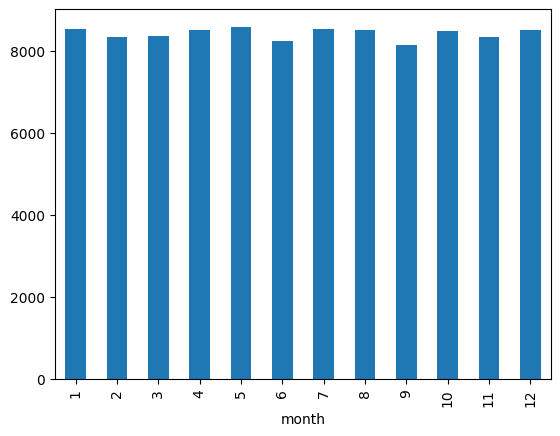

In [50]:
data.groupby(data['month'])['Incident_Count'].sum().plot(kind='bar')

In [51]:
pd.crosstab(data["Location"], data["Severity"])

Severity,High,Low,Medium
Location,,,
Assembly Line,805,5098,2500
Hangar,834,5010,2512
Maintenance Bay,812,5144,2470
Runway,889,5082,2519
Storage Area,867,5109,2415
Tool Room,869,5032,2472


In [52]:
pd.crosstab(data["Shift"], data["Severity"])

Severity,High,Low,Medium
Shift,,,
Evening,1711,10186,4959
Morning,1644,10209,5024
Night,1721,10080,4905


In [54]:
data.groupby("Location")["Incident_Count"].sum()

,Incident_Count
Location,
Assembly Line,16841
Hangar,16726
Maintenance Bay,16874
Runway,17137
Storage Area,16878
Tool Room,16701


In [55]:
location_share = data.groupby("Location")["Incident_Count"].sum()

location_share_pct = (location_share / location_share.sum()) * 100

location_share_pct.sort_values(ascending=False)

,Incident_Count
Location,
Runway,16.940993
Storage Area,16.684955
Maintenance Bay,16.681001
Assembly Line,16.648378
Hangar,16.534694
Tool Room,16.509980


In [56]:
pareto = data.groupby("Object_Type")["Incident_Count"].sum().sort_values(ascending=False)

pareto_cum = pareto.cumsum() / pareto.sum()

pareto_df = pd.DataFrame({
    "Incidents": pareto,
    "Cumulative %": pareto_cum
})

pareto_df

,Incidents,Cumulative %
Object_Type,,
Wire,17122,0.169262
Plastic,17026,0.337574
Bolt/Nut,16919,0.504829
Metal Scrap,16899,0.671886
Packaging Material,16699,0.836966
Tool,16492,1.000000


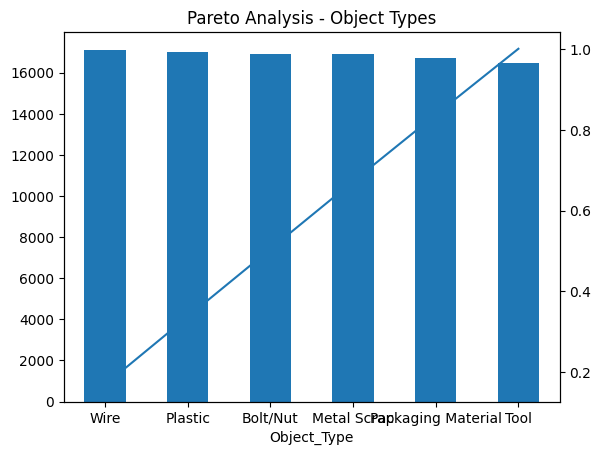

In [57]:

pareto.plot(kind="bar")
pareto_cum.plot(secondary_y=True)

plt.title("Pareto Analysis - Object Types")
plt.show()

In [58]:
high_severnity = data[data['Severity'] == 'High']

In [60]:
high_severnity.groupby('Location')['Incident_Count'].sum().sort_values(ascending=False)

,Incident_Count
Location,
Runway,1790
Tool Room,1724
Storage Area,1721
Hangar,1675
Assembly Line,1627
Maintenance Bay,1615


In [61]:
dept_risk = data.groupby("Department")["Incident_Count"].sum().sort_values(ascending=False)
dept_risk

,Incident_Count
Department,
Quality,25433
Maintenance,25388
Production,25291
Logistics,25045


In [62]:
weather_impact = data.groupby("Weather_Condition")["Incident_Count"].sum().sort_values(ascending=False)
weather_impact

,Incident_Count
Weather_Condition,
Rainy,25788
Humid,25349
Dusty,25297
Clear,24723


In [63]:
inspection = data.groupby("Inspection_Type")["Incident_Count"].sum()
inspection

,Incident_Count
Inspection_Type,
Random Inspection,33349
Routine Check,33969
Safety Audit,33839


In [64]:
top_locations = data.groupby("Location")["Incident_Count"].sum().nlargest(3)
top_locations

,Incident_Count
Location,
Runway,17137
Storage Area,16878
Maintenance Bay,16874
